# Linear Regression — Kaggle: World Happiness Report

**Dataset:** [World Happiness Report](https://www.kaggle.com/datasets/obaidhere/world-happiness-report)  
**Task:** Predict a country's **Happiness Score** from socio-economic indicators.

**Download first:**
```bash
kaggle datasets download -d obaidhere/world-happiness-report \
    -p ../../data/world_happiness --unzip
```

**Features used:**
- GDP per capita
- Social support
- Healthy life expectancy
- Freedom to make life choices
- Generosity
- Perceptions of corruption

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import sys
sys.path.insert(0, '../..')
from src.utils import set_style, regression_report

set_style()
np.random.seed(42)

## 1. Load & Inspect

In [2]:
DATA_DIR = Path('../../data/world_happiness')

# The dataset may have different file names per year — glob all CSVs
csv_files = sorted(DATA_DIR.glob('*.csv'))
print('CSV files found:', [f.name for f in csv_files])

# Load and concatenate across years if multiple files exist
dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f)
    dfs.append(df_tmp)

df_raw = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
print(f'\nShape: {df_raw.shape}')
df_raw.head()

CSV files found: ['2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']

Shape: (782, 30)


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,Trust..Government.Corruption.,Dystopia.Residual,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print('Columns:', df_raw.columns.tolist())
print('\nNull counts:\n', df_raw.isnull().sum())
df_raw.describe()

Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Health..Life.Expectancy.', 'Trust..Government.Corruption.', 'Dystopia.Residual', 'Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Perceptions of corruption']

Null counts:
 Country                          312
Region                           467
Happiness Rank                   467
Happiness Score                  467
Standard Error                   624
Economy (GDP per Capita)         467
Family                           312
Health (Life Expectancy)         467
Freedom                          312
Trust (Governme

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,...,Health..Life.Expectancy.,Trust..Government.Corruption.,Dystopia.Residual,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption
count,315.000000,315.000000,158.000000,315.000000,470.000000,315.000000,470.000000,315.000000,782.000000,315.000000,...,155.000000,155.000000,155.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,311.000000
mean,79.238095,5.378949,0.047885,0.899837,0.990347,0.594054,0.402828,0.140532,0.218576,2.212032,...,0.551341,0.123120,1.850238,78.500000,5.391506,0.898298,1.211026,0.661295,0.423538,0.111299
std,45.538922,1.141531,0.017146,0.410780,0.318707,0.240790,0.150356,0.115490,0.122321,0.558728,...,0.237073,0.101661,0.500028,45.104737,1.114631,0.394592,0.300310,0.252724,0.156024,0.095365
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580,...,0.000000,0.000000,0.377914,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,4.510000,0.037268,0.594900,0.793000,0.419645,0.297615,0.061315,0.130000,1.884135,...,0.369866,0.057271,1.591291,39.750000,4.514250,0.609500,1.055750,0.488250,0.322500,0.050000
50%,79.000000,5.286000,0.043940,0.973060,1.025665,0.640450,0.418347,0.106130,0.201982,2.211260,...,0.606042,0.089848,1.832910,78.500000,5.379500,0.960000,1.265500,0.699000,0.449500,0.082000
75%,118.500000,6.269000,0.052300,1.229000,1.228745,0.787640,0.516850,0.178610,0.278832,2.563470,...,0.723008,0.153296,2.144654,117.250000,6.176000,1.219500,1.457500,0.858000,0.540250,0.140500
max,158.000000,7.587000,0.136930,1.824270,1.610574,1.025250,0.669730,0.551910,0.838075,3.837720,...,0.949492,0.464308,3.117485,156.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.457000


## 2. Clean & Select Features

> Column names vary slightly by year — adjust the mapping below if needed after inspection.

In [4]:
# Normalise column names (lowercase, replace spaces)
df_raw.columns = (
    df_raw.columns
          .str.lower()
          .str.strip()
          .str.replace(' ', '_')
          .str.replace('-', '_')
)

# Common column candidates for the happiness score target
target_candidates = ['happiness_score', 'score', 'life_ladder', 'happiness.score']
target_col = next((c for c in target_candidates if c in df_raw.columns), None)
print(f'Target column: {target_col}')

# Feature candidates — schema varies by year;
# restrict to those with >50 % coverage in rows where the target exists
feature_candidates = [
    'gdp_per_capita', 'economy_(gdp_per_capita)', 'log_gdp_per_capita',
    'social_support', 'family',
    'healthy_life_expectancy', 'health_(life_expectancy)',
    'freedom_to_make_life_choices', 'freedom',
    'generosity',
    'perceptions_of_corruption', 'trust_(government_corruption)',
]
target_mask = df_raw[target_col].notna()
feature_cols = [
    c for c in feature_candidates
    if c in df_raw.columns and df_raw.loc[target_mask, c].notna().mean() > 0.5
]
print(f'Features found: {feature_cols}')

Target column: happiness_score
Features found: ['economy_(gdp_per_capita)', 'family', 'health_(life_expectancy)', 'freedom', 'generosity', 'trust_(government_corruption)']


In [5]:
# Keep only relevant columns and drop NaNs
keep = [target_col] + feature_cols
df = df_raw[keep].dropna().copy()
print(f'Clean dataset: {df.shape}')
df.head()

Clean dataset: (315, 7)


,happiness_score,economy_(gdp_per_capita),family,health_(life_expectancy),freedom,generosity,trust_(government_corruption)
0,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


## 3. EDA

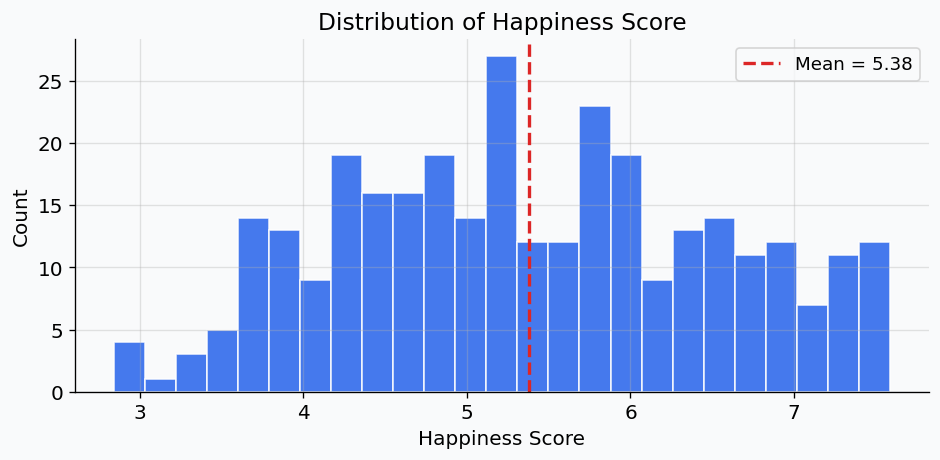

In [6]:
# Distribution of happiness score
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[target_col], bins=25, color='#2563EB', edgecolor='white', alpha=0.85)
ax.axvline(df[target_col].mean(), color='#DC2626', lw=2, linestyle='--',
           label=f'Mean = {df[target_col].mean():.2f}')
ax.set_xlabel('Happiness Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Happiness Score')
ax.legend()
plt.tight_layout()
plt.show()

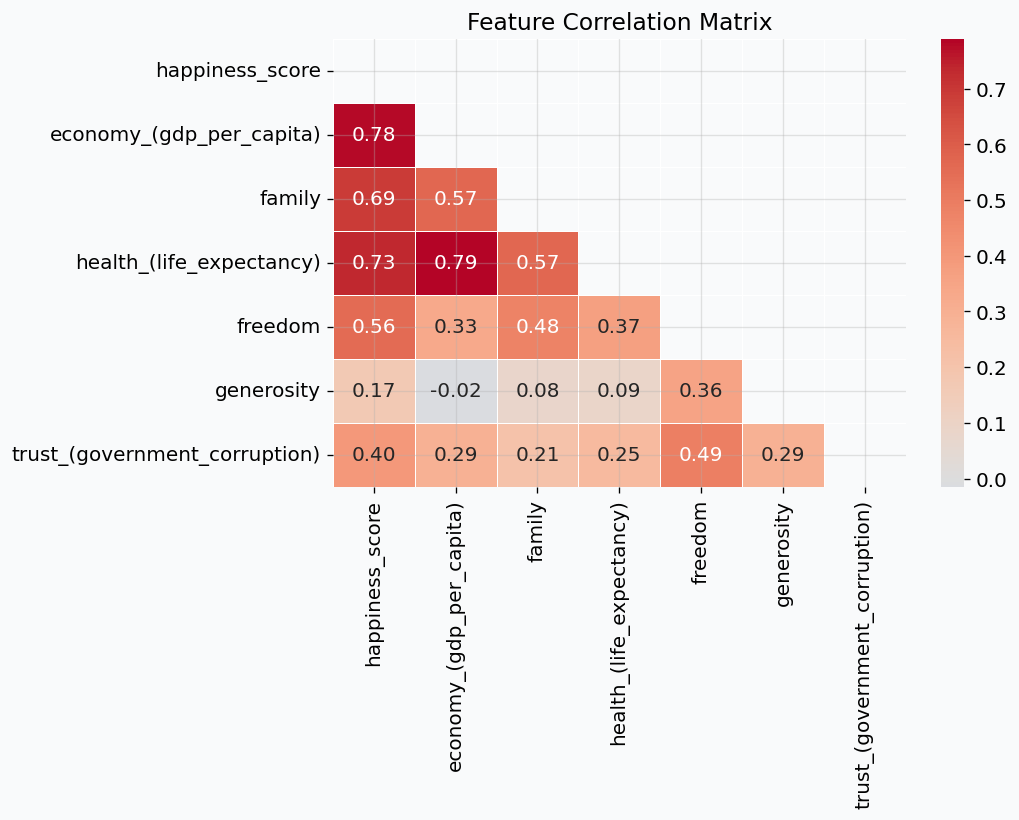

In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[keep].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
# Top correlated features with target
target_corr = corr[target_col].drop(target_col).sort_values(ascending=False)
print('Correlation with Happiness Score:')
print(target_corr.to_string())

Correlation with Happiness Score:
economy_(gdp_per_capita)         0.779171
health_(life_expectancy)         0.734491
family                           0.693547
freedom                          0.556414
trust_(government_corruption)    0.397989
generosity                       0.168272


## 4. Build & Train Model

In [9]:
X = df[feature_cols].values
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0)),
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('Test metrics:')
regression_report(y_test, y_pred)

Test metrics:
  MSE  : 0.1974
  RMSE : 0.4443
  MAE  : 0.3534
  R²   : 0.8663


{'mse': 0.19740226627867466,
 'rmse': np.float64(0.44429974823161295),
 'mae': 0.3534107540232095,
 'r2': 0.8663426188376251}

## 5. Feature Importance (Coefficients)

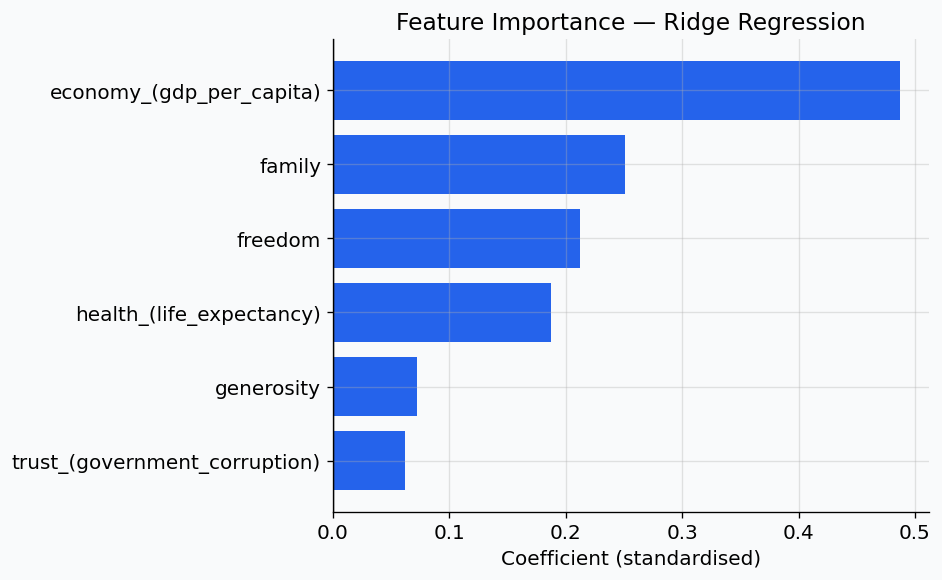

In [10]:
coefs = pipe.named_steps['model'].coef_
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': coefs})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#DC2626' if v < 0 else '#2563EB' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient (standardised)')
ax.set_title('Feature Importance — Ridge Regression')
plt.tight_layout()
plt.show()

## 6. Predicted vs Actual

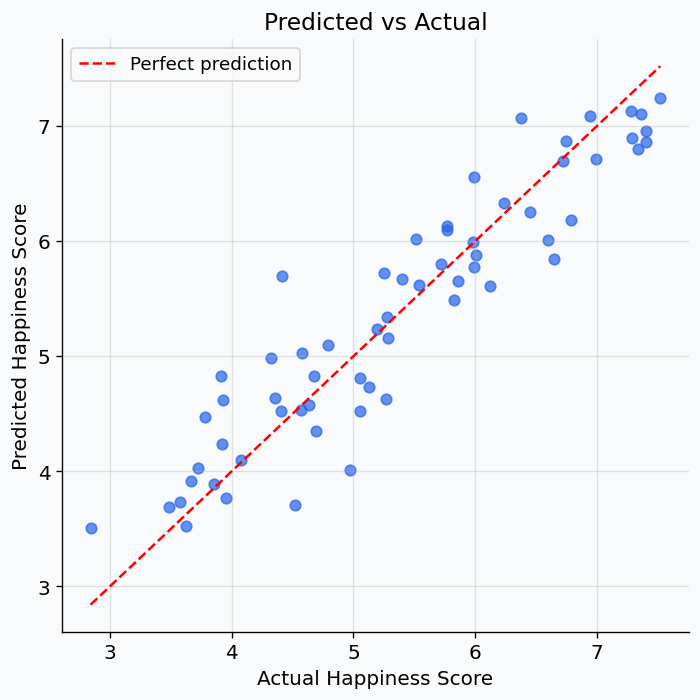

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.7, color='#2563EB', s=40)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Happiness Score')
ax.set_ylabel('Predicted Happiness Score')
ax.set_title('Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Cross-Validation

In [12]:
cv_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')
print(f'5-fold CV R²: {np.round(cv_r2, 4)}')
print(f'Mean R²     : {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}')

5-fold CV R²: [ 0.1186 -1.4823  0.7471 -0.8532 -0.0924]
Mean R²     : -0.3124  ±  0.7769


## Recap

Applied linear regression on a real Kaggle dataset:

1. **EDA** — histograms, correlation heatmap to understand feature-target relationships.
2. **Pipeline** — combined `StandardScaler` + `Ridge` to handle varying feature scales.
3. **Coefficients** — revealed which socio-economic factors most drive happiness.
4. **Cross-validation** — gave honest performance estimate without data leakage.

**Next:** [Gradient Descent — Math Intuition →](../04_gradient_descent/01_math_intuition.ipynb)